<a href="https://colab.research.google.com/github/theSadiqali/-COVID-19-cases-by-country/blob/main/Titanic%20Survival%20Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle pandas numpy scikit-learn matplotlib seaborn

In [2]:
from google.colab import files
files.upload()

Saving titanic.zip to titanic.zip


{'titanic.zip': b'PK\x03\x04-\x00\x00\x00\x08\x00&\x12\x8bOA\xaa\xebr\xff\xff\xff\xff\xff\xff\xff\xff\x15\x00\x14\x00gender_submission.csv\x01\x00\x10\x00\xba\x0c\x00\x00\x00\x00\x00\x00h\x03\x00\x00\x00\x00\x00\x00-\x961\x8e\x1d7\x10Ds\x03\xbe\xc9\x06S\xd5$\xbby\x04g\x02t\x02\x01Z\x08J\x1cH\xb0\xce\xef\xbf[/*p\xf6\xe3\xa1\x9a3O\xad/\xdf~\xff~\xff\xf7\xc7\xfb\xaf\x7f\xbe\xbf}\xfd\xef\xd7\x9f\x9f\x7f\xde\xbf\xff\xfd\xd7\\\xbf=\x1fQo\xfa\x88\x95\xd3N\x9c<\xec\x9c&\xa7\xfbq\xba\xcf\xf3q\xba\x8frr\xa2\x12+\x7f\xdb9\x9d\x9c:1y\x18\x8aB\x91\x12\xa1(\x14\x85\xa2P\x14\x8a:\xa7\xc9)\x14?\x89tq(\x0e\xc5\xa1x\'N\x1e\x86\xe2P|?\xa3B\xa9P*\x94\n\xa5V"\x94J\x97\n\xa52Q\xa5\xcb\xcaD+\x13\xadPV(+]V(+]V(+\x94\x15\xcaN\x97\x1d\xca\x0ee\x87\xb2\xd3e\x87\xb2C\xd9\xb9\xdd\x9d\x89v(\'\x94\x13\xcaq"\x94\x93.\'\xb7{2\xd1I\x97\x93.\'\xf7\xd2\xa1t(\x9d.\x1dJ\xa7K\x87\xd2\xe9\xd2\xa1t\xbat(\x93{\x99\xdc\xee\xa4\xcb\x842\xe92\xa1L(\x13\xca\x842\x99\xe8\x86rC\xb9\xa1\xdcP\xf2\xed\xde|\xbb7\xdf\xee\xcd\xb7{o&\xca\x

In [3]:
import zipfile
import os

zip_path = 'titanic.zip'
extract_dir = 'titanic'

# Create a folder to extract files
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Extract the zip files
if os.path.exists(zip_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
  print(f"Zip file extracted to '{extract_dir}' folder.")
else:
  print(f"The file '{zip_path}' does not exist.")
  raise FileNotFoundError('Zip file missing.')

# Check extracted files
print('Files in titanic_data:', os.listdir(extract_dir))

Zip file extracted to 'titanic' folder.
Files in titanic_data: ['gender_submission.csv', 'test.csv', 'train.csv']


In [4]:
import pandas as pd    # Required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import zipfile
import os

In [5]:
# step 1 extract the uploaded titanic.zip
zip_path = 'titanic.zip'
extract_dir = 'titanic'

# Create a folder to extract the files
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Create a folder to extract files
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

# Extract the zip files
if os.path.exists(zip_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
  print(f'Zip file extracted to {extract_dir} folder.')
else:
  print(f'The file {zip_path} does not exist.')
  raise FileNotFoundError('Zip file missing')

# Check extracted files
print('Files in titanic_data:', os.listdir(extract_dir))

# Step 2: Load the data
train_data = pd.read_csv(os.path.join(extract_dir, 'train.csv'))
test_data = pd.read_csv(os.path.join(extract_dir, 'test.csv'))

# Step 3: Look at the data
print('/nDataset Info:')
print(train_data.info())
print('/nFirst few rows of the training data:')
print(train_data.head())

print('\nSummary statistics of the training data:')
print(train_data.describe())

Zip file extracted to titanic folder.
Files in titanic_data: ['gender_submission.csv', 'test.csv', 'train.csv']
/nDataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
/nFirst few rows of the training data:
   PassengerId  Survived  Pclass  \
0            1         0       3   


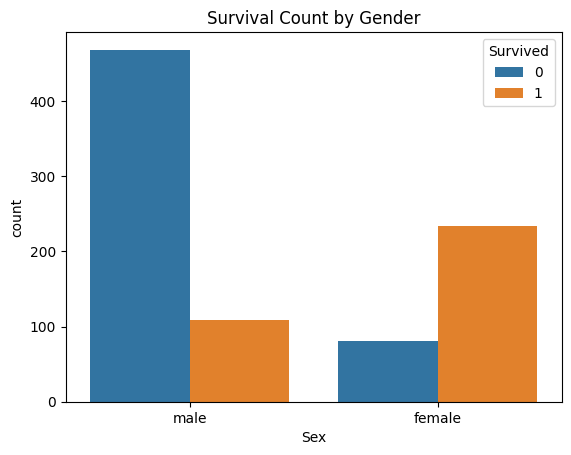

In [6]:
# step 4 show a plot of survival by gender
sns.countplot(x= 'Sex', hue= 'Survived', data= train_data)
plt.title('Survival Count by Gender')
plt.show()


In [7]:
# step 5: CLEAN THE DATA
# Fill missing ' Age ' with the middle value
train_data['Age'].fillna(train_data['Age'].median(), inplace= True)
test_data['Age'].fillna(test_data['Age'].median(), inplace= True)

/tmp/ipython-input-7-148359026.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Age'].fillna(train_data['Age'].median(), inplace= True)
/tmp/ipython-input-7-148359026.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [8]:
# fill th misssing ' Embaraked with the most common value
train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace= True)


/tmp/ipython-input-8-1191649348.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Embarked'].fillna(train_data['Embarked'].mode()[0], inplace= True)


In [9]:
# Step 2: Load the training data and inspect columns
train_data = pd.read_csv(os.path.join(extract_dir, 'train.csv'))
print("\nColumns in train_data:", train_data.columns.tolist())
print("\nFirst 5 rows of train_data:")
print(train_data.head())


Columns in train_data: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows of train_data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85   

In [10]:
# Remove columns we don’t need (only drop if they exist)
columns_to_drop = ['Cabin', 'Ticket', 'Name', 'PassengerId']
train_columns_to_drop = [col for col in columns_to_drop if col in train_data.columns]
train_data = train_data.drop(train_columns_to_drop, axis=1)

In [11]:
# Save PassengerId for submission and drop from test_data
if 'PassengerId' in test_data.columns:
    test_passenger_ids = test_data['PassengerId']
else:
    print("Warning: 'PassengerId' not found in test_data. Generating fallback IDs.")
    test_passenger_ids = pd.Series(range(892, 892 + len(test_data)))  # Standard Titanic test.csv starts at 892
test_columns_to_drop = [col for col in columns_to_drop if col in test_data.columns]

In [14]:
# Change sex to numbers (male = 0, female=1) if exists
if 'Sex' in train_data.columns and 'Sex' in test_data.columns:
  train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
  test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})


In [15]:
# Change Embaraked to number if exists
if 'Embaraed' in train_data.columns and 'Embarked' in test_data.columns:
  train_data = pd.get_dummies(train_data, columns = ['Embaked'], prefix = ['Embarked'], drop_first = True)
  test_data = pd.get_dummies(test_data, columns = ['Embarked'], prefix = ['Embarked'], drop_first = True)

In [16]:
# Ensure  train and test have the same columns after get_dummies
missing_cols = set(train_data.columns) - set(test_data.columns)
for col in missing_cols:
  test_data[col] = 0
  test_data = test_data[train_data.columns] # Align columns


In [17]:
# Fill missing 'Fare' in test data
if 'Fare' in test_data.columns:
  test_data['Fare'].fillna(test_data['Fare'].median(), inplace= True)

/tmp/ipython-input-17-1965017134.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Fare'].fillna(test_data['Fare'].median(), inplace= True)


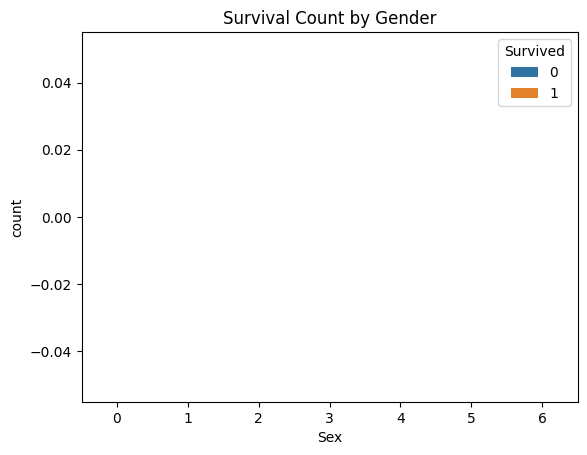

In [19]:
# Step 5: Show a plot of survival by gender
if 'Sex' in train_data.columns and 'Survived' in train_data.columns:
    sns.countplot(x='Sex', hue='Survived', data=train_data)
    plt.title('Survival Count by Gender')
    plt.show()

In [20]:
# Step 6: Prepare data for model
if 'Survived' in train_data.columns:
    X = train_data.drop('Survived', axis=1)  # Features
    y = train_data['Survived']  # Target
else:
    raise KeyError("Survived column not found in train_data")


/tmp/ipython-input-23-2055286188.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)


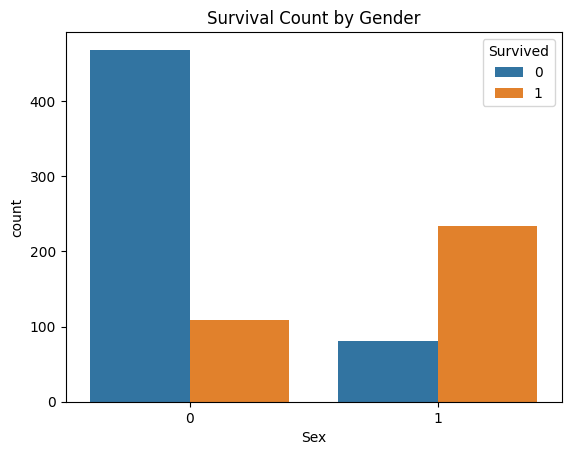


Accuracy on validation set: 0.7988826815642458
Submission file created: submission.csv


In [23]:
# Fill missing 'Fare' in test data
if 'Fare' in test_data.columns:
    test_data['Fare'].fillna(test_data['Fare'].median(), inplace=True)

# Step 5: Show a plot of survival by gender
if 'Sex' in train_data.columns and 'Survived' in train_data.columns:
    sns.countplot(x='Sex', hue='Survived', data=train_data)
    plt.title('Survival Count by Gender')
    plt.show()

# Step 6: Prepare data for model
if 'Survived' in train_data.columns:
    X = train_data.drop('Survived', axis=1)  # Features
    y = train_data['Survived']  # Target
else:
    raise KeyError("Survived column not found in train_data")

# Step 7: Split data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 9: Check how good the model is
y_pred = model.predict(X_val)
print("\nAccuracy on validation set:", accuracy_score(y_val, y_pred))

# Step 10: Make predictions for test data
test_predictions = model.predict(test_data)

# Step 11: Create submission file
submission = pd.DataFrame({'PassengerId': test_passenger_ids, 'Survived': test_predictions})
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")